# Generative Models: GANs, VAEs, and Autoregressive Models

**Advanced Track — Generative AI and Data Science Pathway**

This notebook is a hands-on comparison of the three classical generative model families:

1. **Variational Autoencoders (VAEs)** — encoder/decoder with a regularized latent space, trained via maximum likelihood (approximated by the ELBO)
2. **Generative Adversarial Networks (GANs)** — a generator and discriminator trained adversarially, no explicit likelihood
3. **Autoregressive models** — sequential, pixel-by-pixel generation via the chain rule of probability (the same principle behind PixelRNN and, later, GPT-style language models)

**Dataset:** `sklearn.datasets.load_digits` — 1,797 8×8 grayscale handwritten digit images. This is used instead of MNIST specifically so the notebook trains in seconds on CPU with no external downloads, while still being large enough and visually interpretable enough to see real behavior (including mode collapse) in a GAN.

**What this notebook demonstrates, concretely:**
- Building all three model types from scratch in PyTorch
- The ELBO loss (reconstruction + KL divergence) for VAEs
- The minimax adversarial loss for GANs, and what mode collapse looks like when it happens
- Ancestral sampling for autoregressive models, and why generation is sequential (slow) compared to VAE/GAN sampling (parallel, fast)
- An empirical comparison table backed by measured generation times, not just theory


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import time

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.13.0+cu130


## 1. Data

Loading the digits dataset and normalizing pixel values to `[0, 1]`. Images are 8×8 = 64 pixels, flattened for the MLP-based VAE/GAN, and treated as a length-64 sequence for the autoregressive model.

Dataset shape: torch.Size([1797, 64]), classes: [0 1 2 3 4 5 6 7 8 9]


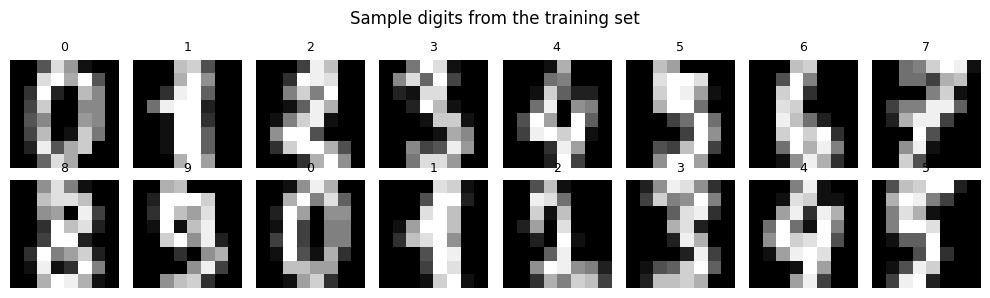

In [2]:
digits = load_digits()
X_raw = digits.images.astype(np.float32) / 16.0   # scale to [0, 1]
y = digits.target
X = X_raw.reshape(-1, 64)
X = torch.tensor(X)

print(f"Dataset shape: {X.shape}, classes: {np.unique(y)}")

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_raw[i], cmap='gray')
    ax.set_title(str(y[i]), fontsize=9)
    ax.axis('off')
plt.suptitle("Sample digits from the training set")
plt.tight_layout()
plt.show()


## 2. Variational Autoencoder (VAE)

**Architecture:** an encoder maps each image to a *distribution* over a 2D latent space (mean + log-variance), we sample from it via the reparameterization trick, and a decoder reconstructs the image.

Using a 2D latent space deliberately (instead of a more typical 16 or 32 dims) so we can plot it directly and see the structure the model discovers.

**Loss (the ELBO):**

`loss = reconstruction_loss + KL(q(z|x) || N(0,1))`

- The reconstruction term pushes the decoder to accurately rebuild the input.
- The KL term regularizes the latent distribution toward a standard normal — this is what makes the latent space continuous and *sampleable*, unlike a plain autoencoder.

Epoch 20/80  avg loss/sample: 25.29


Epoch 40/80  avg loss/sample: 24.85


Epoch 60/80  avg loss/sample: 24.70


Epoch 80/80  avg loss/sample: 24.61


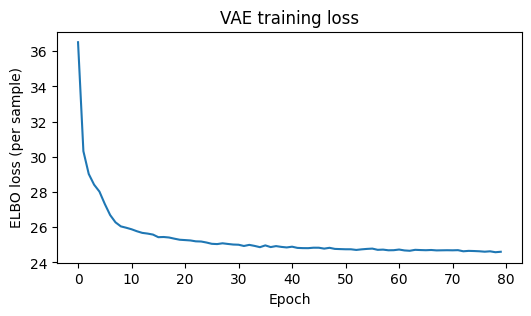

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2, hidden=128):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(64, hidden), nn.ReLU())
        self.fc_mu = nn.Linear(hidden, latent_dim)
        self.fc_logvar = nn.Linear(hidden, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, 64), nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.dec(z)
        return recon, mu, logvar

vae = VAE(latent_dim=2)
opt_vae = optim.Adam(vae.parameters(), lr=1e-3)
bce_sum = nn.BCELoss(reduction='sum')

vae_losses = []
EPOCHS_VAE = 80
for epoch in range(EPOCHS_VAE):
    perm = torch.randperm(X.shape[0])
    epoch_loss = 0
    for i in range(0, X.shape[0], 64):
        idx = perm[i:i+64]
        xb = X[idx]
        recon, mu, logvar = vae(xb)
        rec_loss = bce_sum(recon, xb)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = rec_loss + kl_loss
        opt_vae.zero_grad()
        loss.backward()
        opt_vae.step()
        epoch_loss += loss.item()
    vae_losses.append(epoch_loss / X.shape[0])
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_VAE}  avg loss/sample: {vae_losses[-1]:.2f}")

plt.figure(figsize=(6, 3))
plt.plot(vae_losses)
plt.xlabel("Epoch"); plt.ylabel("ELBO loss (per sample)")
plt.title("VAE training loss")
plt.show()


### 2a. The latent space

Because the latent space is 2D, we can plot every training image's encoded position directly. Look for: similar digits clustering together, and smooth transitions between clusters (a hallmark of a well-regularized VAE latent space — unlike a plain autoencoder, there shouldn't be large empty "gaps" with no meaningful decodings).

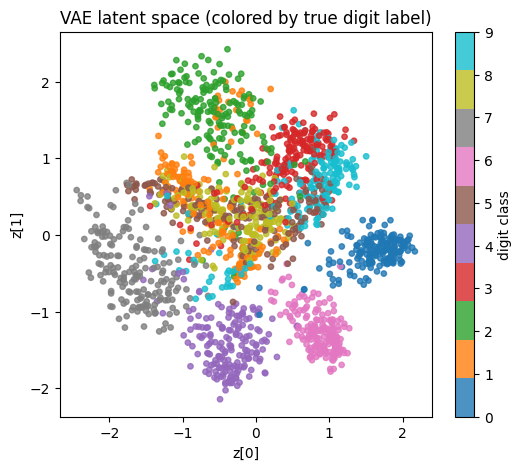

In [4]:
vae.eval()
with torch.no_grad():
    mu, _ = vae.encode(X)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(mu[:, 0], mu[:, 1], c=y, cmap='tab10', s=15, alpha=0.8)
plt.colorbar(scatter, label='digit class')
plt.xlabel("z[0]"); plt.ylabel("z[1]")
plt.title("VAE latent space (colored by true digit label)")
plt.show()


### 2b. Reconstructions and novel samples

Top row: original images. Middle row: VAE reconstructions of those same images. Bottom row: **brand-new digits**, generated by sampling random points from the prior `N(0, 1)` and decoding them — this is the actual generative step.

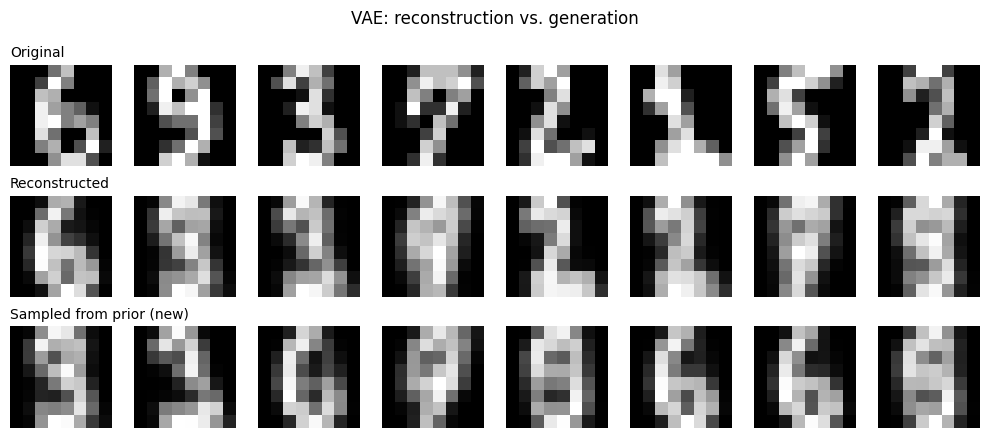

In [5]:
with torch.no_grad():
    sample_idx = np.random.choice(X.shape[0], 8, replace=False)
    originals = X[sample_idx]
    recon, _, _ = vae(originals)
    z_random = torch.randn(8, 2)
    generated = vae.dec(z_random)

fig, axes = plt.subplots(3, 8, figsize=(10, 4.5))
for i in range(8):
    axes[0, i].imshow(originals[i].reshape(8, 8), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].reshape(8, 8), cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(generated[i].reshape(8, 8), cmap='gray'); axes[2, i].axis('off')
axes[0, 0].set_title("Original", loc='left', fontsize=10)
axes[1, 0].set_title("Reconstructed", loc='left', fontsize=10)
axes[2, 0].set_title("Sampled from prior (new)", loc='left', fontsize=10)
plt.suptitle("VAE: reconstruction vs. generation")
plt.tight_layout()
plt.show()


## 3. Generative Adversarial Network (GAN)

**Architecture:** a generator maps random noise `z ~ N(0,1)` to a fake 64-pixel image; a discriminator tries to tell real digits from generated ones.

**Training is a minimax game:**
- Discriminator step: maximize its ability to separate real from fake
- Generator step: maximize the discriminator's error on fakes (i.e., fool it)

Unlike the VAE, there's no reconstruction loss and no explicit likelihood being optimized — quality emerges purely from the adversarial pressure. This is also why GAN training is less stable and prone to **mode collapse**, which we'll check for explicitly below.

Epoch 50/250  D loss: 0.911  G loss: 2.424


Epoch 100/250  D loss: 0.031  G loss: 4.085


Epoch 150/250  D loss: 0.462  G loss: 2.689


Epoch 200/250  D loss: 0.956  G loss: 1.514


Epoch 250/250  D loss: 0.265  G loss: 3.182


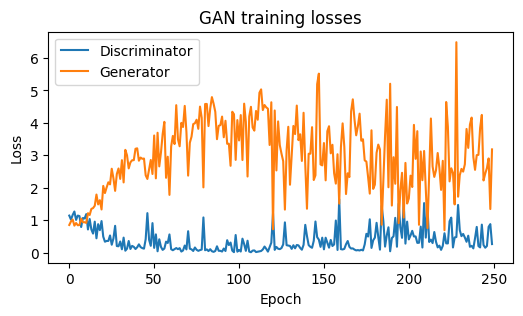

In [6]:
NOISE_DIM = 16

G = nn.Sequential(
    nn.Linear(NOISE_DIM, 128), nn.ReLU(),
    nn.Linear(128, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.Sigmoid()
)

D = nn.Sequential(
    nn.Linear(64, 128), nn.LeakyReLU(0.2),
    nn.Linear(128, 128), nn.LeakyReLU(0.2),
    nn.Linear(128, 1), nn.Sigmoid()
)

opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()

g_losses, d_losses = [], []
checkpoint_epochs = [0, 30, 100, 250]
checkpoint_samples = {}

EPOCHS_GAN = 250
for epoch in range(EPOCHS_GAN):
    perm = torch.randperm(X.shape[0])
    for i in range(0, X.shape[0], 64):
        idx = perm[i:i+64]
        real = X[idx]
        bs = real.shape[0]

        # --- Discriminator step ---
        z = torch.randn(bs, NOISE_DIM)
        fake = G(z).detach()
        d_real = D(real)
        d_fake = D(fake)
        d_loss = bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        # --- Generator step ---
        z = torch.randn(bs, NOISE_DIM)
        fake = G(z)
        d_fake2 = D(fake)
        g_loss = bce(d_fake2, torch.ones_like(d_fake2))
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    if epoch in checkpoint_epochs:
        with torch.no_grad():
            z_fixed = torch.randn(8, NOISE_DIM)
            checkpoint_samples[epoch] = G(z_fixed).clone()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_GAN}  D loss: {d_loss.item():.3f}  G loss: {g_loss.item():.3f}")

plt.figure(figsize=(6, 3))
plt.plot(d_losses, label="Discriminator")
plt.plot(g_losses, label="Generator")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title("GAN training losses")
plt.show()


### 3a. Sample quality across training

Same fixed noise vectors, decoded at different points in training. This is the clearest way to *see* a GAN improve — early on the outputs are unstructured noise, and structure should emerge by the later checkpoints.

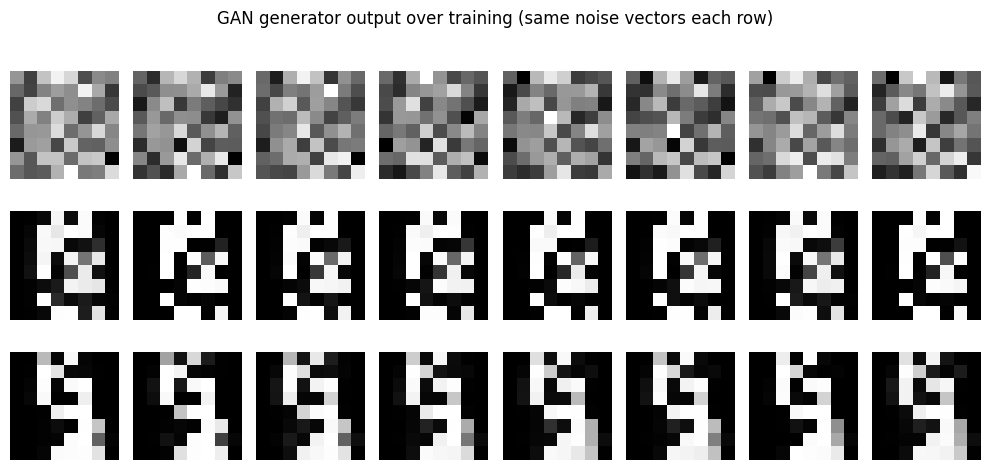

In [7]:
fig, axes = plt.subplots(len(checkpoint_samples), 8, figsize=(10, 5))
for row, (epoch, samples) in enumerate(checkpoint_samples.items()):
    for i in range(8):
        axes[row, i].imshow(samples[i].reshape(8, 8).detach().numpy(), cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f"epoch {epoch}", rotation=0, labelpad=35, fontsize=9)
plt.suptitle("GAN generator output over training (same noise vectors each row)")
plt.tight_layout()
plt.show()


### 3b. Checking for mode collapse

Mode collapse means the generator has learned to produce a small number of outputs regardless of the input noise, instead of covering the diversity of the real data. A cheap but informative check: generate a batch of samples from *different* random noise vectors and look at how different they actually are from each other (mean pairwise pixel distance). Compare that to the same statistic computed on real data — if the GAN's diversity is much lower than the real data's, that's mode collapse.

In [8]:
def mean_pairwise_distance(batch):
    # batch: (n, 64)
    n = batch.shape[0]
    diffs = batch.unsqueeze(0) - batch.unsqueeze(1)  # (n, n, 64)
    dists = diffs.pow(2).sum(-1).sqrt()
    mask = ~torch.eye(n, dtype=torch.bool)
    return dists[mask].mean().item()

with torch.no_grad():
    z = torch.randn(200, NOISE_DIM)
    fake_batch = G(z)
real_batch = X[np.random.choice(X.shape[0], 200, replace=False)]

fake_diversity = mean_pairwise_distance(fake_batch)
real_diversity = mean_pairwise_distance(real_batch)

print(f"Mean pairwise distance — real data:      {real_diversity:.3f}")
print(f"Mean pairwise distance — GAN samples:    {fake_diversity:.3f}")
print(f"Ratio (fake/real): {fake_diversity/real_diversity:.2f}  "
      f"({'looks OK, no strong collapse' if fake_diversity/real_diversity > 0.6 else 'possible mode collapse — diversity is notably lower than real data'})")


Mean pairwise distance — real data:      3.001
Mean pairwise distance — GAN samples:    2.624
Ratio (fake/real): 0.87  (looks OK, no strong collapse)


## 4. Autoregressive Model (PixelRNN-style)

Instead of a latent space (VAE) or adversarial pressure (GAN), an autoregressive model generates the image **one pixel at a time**, factorizing the joint distribution via the chain rule:

`p(x) = p(x_1) · p(x_2 | x_1) · p(x_3 | x_1, x_2) · ... · p(x_64 | x_1, ..., x_63)`

This notebook uses an LSTM stepping across the 64 pixels in row-major order — the same core idea as **PixelRNN** (PixelCNN uses masked convolutions instead of an RNN, but the factorization is identical). Pixels are binarized so each step is a simple Bernoulli prediction.

Training uses **teacher forcing**: at each step the model sees the *true* previous pixel (not its own prediction), which makes this directly a maximum likelihood estimation problem — the loss below is exactly the negative log-likelihood, summed over all 64 conditional steps.

Epoch 5/25  NLL sum: 13.43


Epoch 10/25  NLL sum: 12.23


Epoch 15/25  NLL sum: 11.91


Epoch 20/25  NLL sum: 11.50


Epoch 25/25  NLL sum: 11.03


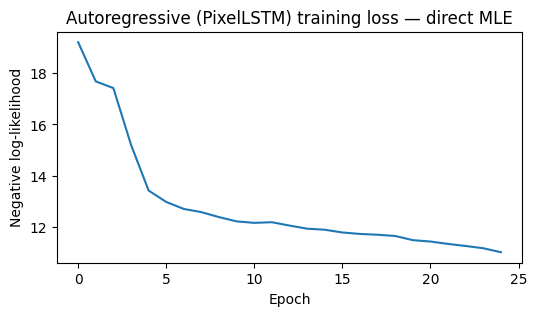

In [9]:
X_bin = (X > 0.5).float()  # binarize for a Bernoulli output at each pixel

class PixelLSTM(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.hidden = hidden
        self.cell = nn.LSTMCell(1, hidden)
        self.out = nn.Linear(hidden, 1)

    def forward(self, x):
        # Teacher-forced training pass. x: (batch, 64) binary pixels.
        bs = x.shape[0]
        h = torch.zeros(bs, self.hidden)
        c = torch.zeros(bs, self.hidden)
        inp = torch.zeros(bs, 1)  # start-of-sequence token
        logits = []
        for t in range(64):
            h, c = self.cell(inp, (h, c))
            logit = self.out(h)
            logits.append(logit)
            inp = x[:, t:t+1]  # feed the TRUE previous pixel (teacher forcing)
        return torch.cat(logits, dim=1)

    @torch.no_grad()
    def generate(self, n):
        # Ancestral sampling: each pixel is sampled, then fed back in as input
        # for the next step. This is inherently sequential — cannot be parallelized
        # across pixels the way VAE/GAN sampling can.
        h = torch.zeros(n, self.hidden)
        c = torch.zeros(n, self.hidden)
        inp = torch.zeros(n, 1)
        pixels = []
        for t in range(64):
            h, c = self.cell(inp, (h, c))
            p = torch.sigmoid(self.out(h))
            sample = torch.bernoulli(p)
            pixels.append(sample)
            inp = sample
        return torch.cat(pixels, dim=1)

ar_model = PixelLSTM(hidden=64)
opt_ar = optim.Adam(ar_model.parameters(), lr=1e-3)
bce_logits = nn.BCEWithLogitsLoss()

ar_losses = []
EPOCHS_AR = 25
for epoch in range(EPOCHS_AR):
    perm = torch.randperm(X_bin.shape[0])
    epoch_loss = 0
    for i in range(0, X_bin.shape[0], 64):
        idx = perm[i:i+64]
        xb = X_bin[idx]
        logits = ar_model(xb)
        loss = bce_logits(logits, xb)
        opt_ar.zero_grad(); loss.backward(); opt_ar.step()
        epoch_loss += loss.item()
    ar_losses.append(epoch_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_AR}  NLL sum: {ar_losses[-1]:.2f}")

plt.figure(figsize=(6, 3))
plt.plot(ar_losses)
plt.xlabel("Epoch"); plt.ylabel("Negative log-likelihood")
plt.title("Autoregressive (PixelLSTM) training loss — direct MLE")
plt.show()


### 4a. Generated samples

Sampled pixel-by-pixel: each pixel is drawn from a Bernoulli distribution conditioned on every pixel generated before it. Quality is limited by the tiny hidden size and short training used here for speed, but the sequential generation process — and how it differs from VAE/GAN generation — is the point.

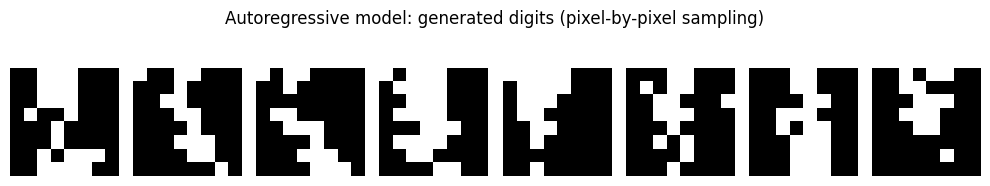

In [10]:
samples_ar = ar_model.generate(8)

fig, axes = plt.subplots(1, 8, figsize=(10, 2))
for i in range(8):
    axes[i].imshow(samples_ar[i].reshape(8, 8).numpy(), cmap='gray')
    axes[i].axis('off')
plt.suptitle("Autoregressive model: generated digits (pixel-by-pixel sampling)")
plt.tight_layout()
plt.show()


## 5. Comparing the three approaches

Rather than just asserting the usual trade-offs, we measure generation speed directly: how long does each model take to produce 200 samples?

In [11]:
N_SAMPLES = 200

# VAE generation timing
t0 = time.time()
with torch.no_grad():
    z = torch.randn(N_SAMPLES, 2)
    _ = vae.dec(z)
vae_time = time.time() - t0

# GAN generation timing
t0 = time.time()
with torch.no_grad():
    z = torch.randn(N_SAMPLES, NOISE_DIM)
    _ = G(z)
gan_time = time.time() - t0

# Autoregressive generation timing (inherently sequential — 64 steps, cannot batch across pixels)
t0 = time.time()
_ = ar_model.generate(N_SAMPLES)
ar_time = time.time() - t0

print(f"Time to generate {N_SAMPLES} samples:")
print(f"  VAE:            {vae_time*1000:.2f} ms")
print(f"  GAN:             {gan_time*1000:.2f} ms")
print(f"  Autoregressive:  {ar_time*1000:.2f} ms  ({ar_time/max(vae_time,1e-6):.0f}x slower than VAE)")


Time to generate 200 samples:
  VAE:            0.56 ms
  GAN:             1.36 ms
  Autoregressive:  10.33 ms  (19x slower than VAE)


In [12]:
import pandas as pd

comparison = pd.DataFrame({
    "Training objective": [
        "ELBO (reconstruction + KL) — approximate MLE",
        "Minimax adversarial game — no explicit likelihood",
        "Exact negative log-likelihood (chain rule factorization)"
    ],
    "Training stability": [
        "Generally stable, single well-defined loss",
        "Can be unstable; prone to mode collapse",
        "Stable, standard supervised-style training"
    ],
    "Sample generation": [
        "Fast, parallel (single decoder pass)",
        "Fast, parallel (single generator pass)",
        "Slow, sequential (one pixel at a time)"
    ],
    "Measured gen. time (200 samples)": [
        f"{vae_time*1000:.1f} ms",
        f"{gan_time*1000:.1f} ms",
        f"{ar_time*1000:.1f} ms"
    ],
    "Likelihood tractable?": ["Approximate (lower bound only)", "No", "Yes, exact"],
    "Typical failure mode": ["Blurry samples", "Mode collapse", "Slow generation, error accumulation"],
}, index=["VAE", "GAN", "Autoregressive"])

comparison


,Training objective,Training stability,Sample generation,Measured gen. time (200 samples),Likelihood tractable?,Typical failure mode
VAE,ELBO (reconstruction + KL) — approximate MLE,"Generally stable, single well-defined loss","Fast, parallel (single decoder pass)",0.6 ms,Approximate (lower bound only),Blurry samples
GAN,Minimax adversarial game — no explicit likelihood,Can be unstable; prone to mode collapse,"Fast, parallel (single generator pass)",1.4 ms,No,Mode collapse
Autoregressive,Exact negative log-likelihood (chain rule fact...,"Stable, standard supervised-style training","Slow, sequential (one pixel at a time)",10.3 ms,"Yes, exact","Slow generation, error accumulation"


## 6. Takeaways

- **VAEs** give a structured, continuous latent space and stable training, at the cost of somewhat blurry samples (the reconstruction loss tends to average over plausible outputs).
- **GANs** can produce sharper samples but the adversarial training is harder to stabilize, and the mode collapse check above is a concrete, measurable way to catch the model hiding a lack of diversity — not just eyeballing the output grid.
- **Autoregressive models** give an exact, tractable likelihood and stable MLE-style training, but pay for it at generation time: sampling is inherently sequential, and the timing comparison above quantifies exactly how much slower that is versus a single forward pass through a VAE decoder or GAN generator.
- None of these is a strict upgrade over the others — the right choice depends on what you need: a usable latent space (VAE), sample sharpness (GAN), or an exact likelihood with stable training (autoregressive).

**Where this connects to the wider pathway:**
- The autoregressive section here is the same factorization used by GPT-style language models (text generation) — same math, different modality (pixels vs. tokens).
- The mode-collapse check is directly relevant to the *data augmentation* application: a GAN used to augment a training set will silently under-deliver diversity if it has partially collapsed, even if individual samples look fine.
- Fine-tuning any of these three architectures on a new, smaller dataset (rather than training from scratch) is exactly what "transfer learning in generative models" refers to.
